# Visualization

Trong bài tập này, bạn sẽ được rèn luyện kĩ năng trực quan hóa. Trực quan hóa ngoài việc hỗ  trợ trong khâu tiền xử lí dữ liệu, còn giúp bạn phân tích và rút ra được các thông tin có ý nghĩa từ dữ liệu

**Tập dữ liệu** được sử dụng được lấy từ trang batdongsan.com.vn

In [2]:
#Import các thư viện cần thiết

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
import random
import math

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/MyDrive/Preprocessing_practice/2.Assignment/Batdongsan.com.vn

/content/drive/MyDrive/Preprocessing_practice/2.Assignment/Batdongsan.com.vn


In [3]:
#Load dữ liệu từ file
newdf = pd.read_csv(r'C:\Users\ThinkBook 15 G5\OneDrive\bai tap AI\ML\ML-homeworks\Hw2\batdongsan.com.vn.csv', dtype = {"month": "string" , "id" : "string"})
print("DONE")

DONE


In [4]:
newdf.columns

Index(['id', 'month', 'project', 'investor', 'square', 'bedrooms', 'bathrooms',
       'direction', 'balcony', 'district', 'ward', 'price'],
      dtype='object')

In [5]:
# Xem 5 hàng dữ liệu đầu tiên, các thông tin ban đầu: df.info(), df.describe(), ...
# Xem 5 hàng đầu
print(newdf.head())

# Kiểm tra tổng quan kiểu dữ liệu và giá trị thiếu
print(newdf.info())

# Xem thống kê mô tả (giá, diện tích, số phòng...)
print(newdf.describe())

         id month                     project  \
0  28086120    12  Vinhomes Smart City Đại Mỗ   
1  28088954    12               Goldmark City   
2  28097966    12        Chung cư IEC Tứ Hiệp   
3  27895887    12         Vinhomes D'Capitale   
4  28056031    12           The Zen Residence   

                                            investor  square  bedrooms  \
0                                  Tập đoàn Vingroup    60.0       3.0   
1  Công ty TNHH Thương mại - Quảng cáo - Xây dựng...   121.0       3.0   
2                                                NaN    70.0       2.0   
3                               Tân Hoàng Minh Group    39.0       1.0   
4                  Công ty TNHH Gamuda Land Việt Nam    97.0       3.0   

   bathrooms direction   balcony     district        ward   price  
0        1.0  Đông-Nam   Tây-Bắc  nam tu liem      dai mo  1560.0  
1        2.0       NaN       NaN  bac tu liem    phu dien  3300.0  
2        2.0   Tây-Bắc  Đông-Nam    thanh tri     tu hie

Đưa ra các câu lệnh để thực hiện các yêu cầu sau:

1. Minh họa boxblot của các trường số như price, bedrooms, square, ...

* Gợi ý: sns.boxplot(data_field)

In [6]:
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

c:\Users\ThinkBook 15 G5\miniconda3.1\envs\ai\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='price'>

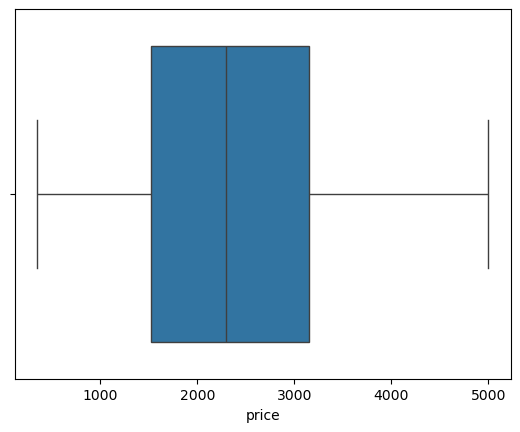

In [8]:
#Code for 'price' field
sns.boxplot(x=newdf['price'])

c:\Users\ThinkBook 15 G5\miniconda3.1\envs\ai\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='square'>

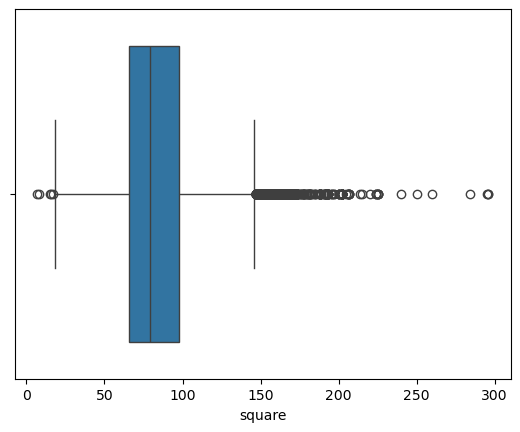

In [9]:
#Code for 'square' field
sns.boxplot(x=newdf['square'])

c:\Users\ThinkBook 15 G5\miniconda3.1\envs\ai\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='bedrooms'>

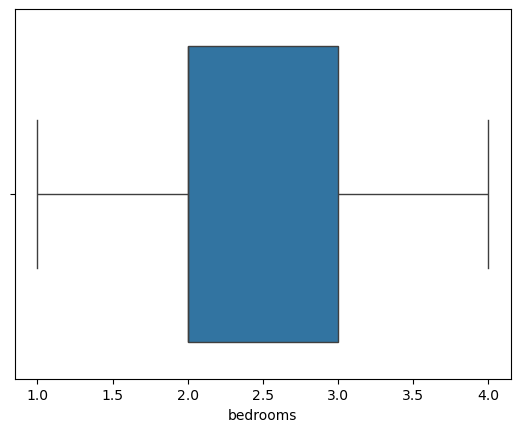

In [10]:
#Code for 'bedrooms' field
sns.boxplot(x=newdf['bedrooms'])

c:\Users\ThinkBook 15 G5\miniconda3.1\envs\ai\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='bathrooms'>

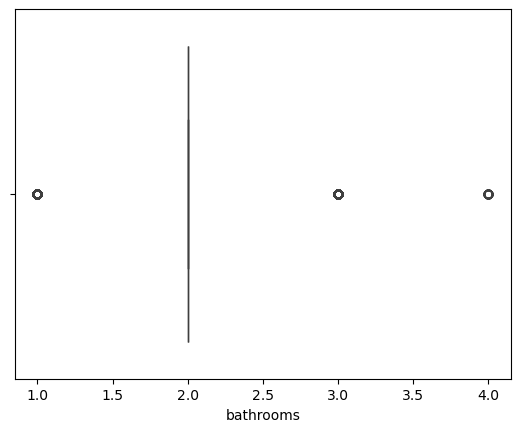

In [11]:
#Code for 'bathrooms' field
sns.boxplot(x=newdf['bathrooms'])

2. Cho đoạn code minh họa Biểu đồ thể hiện số bài đăng theo tháng của năm 2020. Hãy thực hiện các yêu cầu cho các câu hỏi dưới đây:

C:\Users\ThinkBook 15 G5\AppData\Local\Temp\ipykernel_3720\1920162332.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')


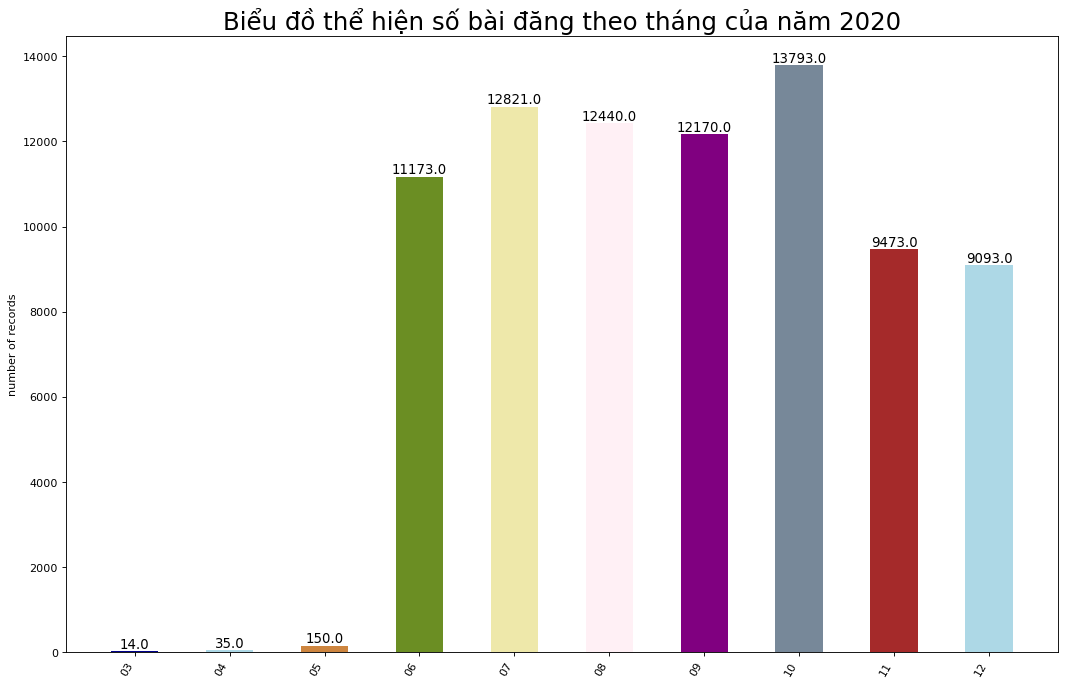

In [12]:
df1 = newdf.groupby('month').size().reset_index(name='number of records')
n = df1['month'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df1['month'], df1['number of records'], color=c, width=.5)
for i, val in enumerate(df1['number of records'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện số bài đăng theo tháng của năm 2020", fontsize=22)
plt.ylabel('number of records')
plt.show()

* Biểu đồ thể hiện giá nhà đất trung bình theo tháng (VND/m2)

C:\Users\ThinkBook 15 G5\AppData\Local\Temp\ipykernel_3720\3276980627.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df2['month'], rotation=60, horizontalalignment='right')


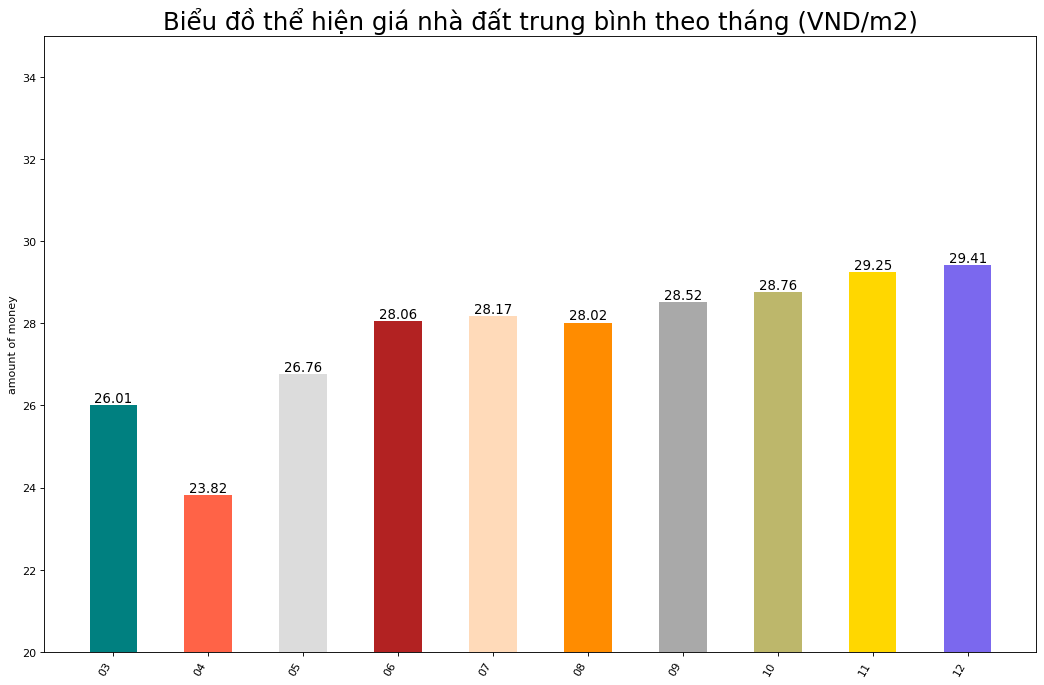

In [17]:
#Code ở đây
# Tạo hàm tính đơn giá và áp dụng vào dataframe copy
def newprice(row):
    return row['price'] / row['square']

dftmp = newdf.copy()
dftmp['pricePerSquare'] = dftmp.apply(newprice, axis=1)

# Tính trung bình theo tháng
df2 = dftmp.groupby('month')['pricePerSquare'].mean().reset_index(name='amount of money')
df2['amount of money'] = df2['amount of money'].apply(lambda x: round(x, 2))

# Vẽ biểu đồ cột
plt.figure(figsize=(16, 10), dpi=80)
plt.bar(df2['month'], df2['amount of money'], color=random.choices(all_colors, k=len(df2)+1), width=0.5)

# Thêm nhãn giá trị
for i, val in enumerate(df2['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight': 500, 'size': 12})

plt.gca().set_xticklabels(df2['month'], rotation=60, horizontalalignment='right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo tháng (VND/m2)", fontsize=22)
plt.ylabel('amount of money')
plt.ylim(20, 35) # Giới hạn trục y để dễ quan sát biến động
plt.show()

* Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)

C:\Users\ThinkBook 15 G5\AppData\Local\Temp\ipykernel_3720\1694501322.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dftmp.loc[dftmp['month'] == '12', "pricePerSquare"],
C:\Users\ThinkBook 15 G5\AppData\Local\Temp\ipykernel_3720\1694501322.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplo

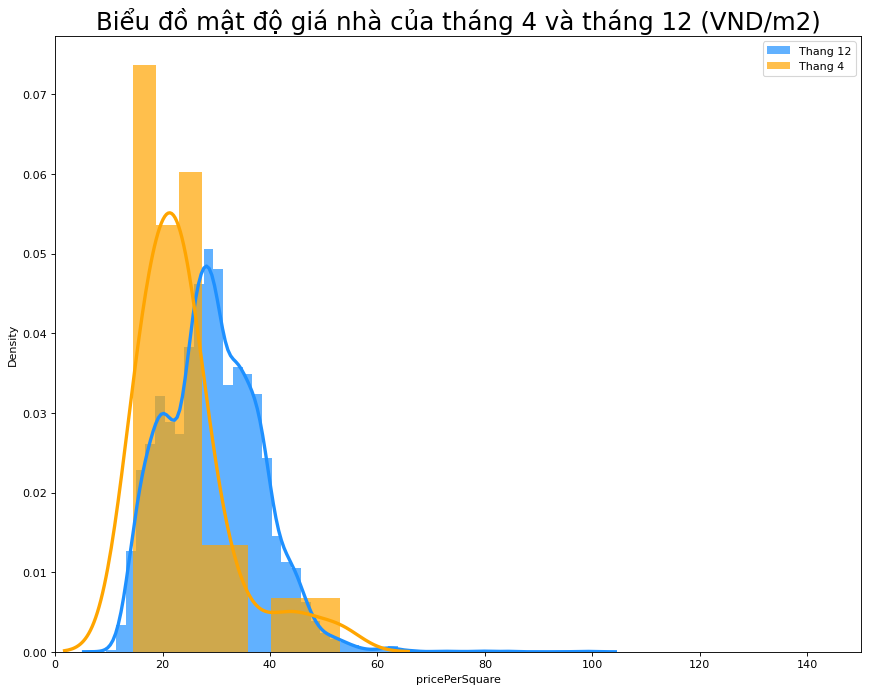

In [19]:
#Gọi ý: sns.displot()
# Thiết lập kích thước biểu đồ
plt.figure(figsize=(13, 10), dpi=80)

# Vẽ biểu đồ mật độ cho tháng 12 (Thang 12) [cite: 213-215]
sns.distplot(dftmp.loc[dftmp['month'] == '12', "pricePerSquare"], 
             color="dodgerblue", label="Thang 12", 
             hist_kws={'alpha': .7}, kde_kws={'linewidth': 3})

# Vẽ biểu đồ mật độ cho tháng 4 (Thang 4) [cite: 216-217]
sns.distplot(dftmp.loc[dftmp['month'] == '04', "pricePerSquare"], 
             color="orange", label="Thang 4", 
             hist_kws={'alpha': .7}, kde_kws={'linewidth': 3})

# Cấu hình trục và tiêu đề [cite: 218-220]
plt.xlim(0, 150)
plt.title('Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)', fontsize=22)
plt.legend()
plt.show()

* Số lượng bất động sản phân theo số lượng bedrooms

c:\Users\ThinkBook 15 G5\miniconda3.1\envs\ai\lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedWriter name=4>
  return process_handler(cmd, _system_body)
c:\Users\ThinkBook 15 G5\miniconda3.1\envs\ai\lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  return process_handler(cmd, _system_body)
c:\Users\ThinkBook 15 G5\miniconda3.1\envs\ai\lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  return process_handler(cmd, _system_body)
C:\Users\ThinkBook 15 G5\AppData\Local\Temp\ipykernel_3720\3969244308.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels = df.apply(lambda x: str(x[0]) + "\n (" + str(x[1]) + ")", axis=1)


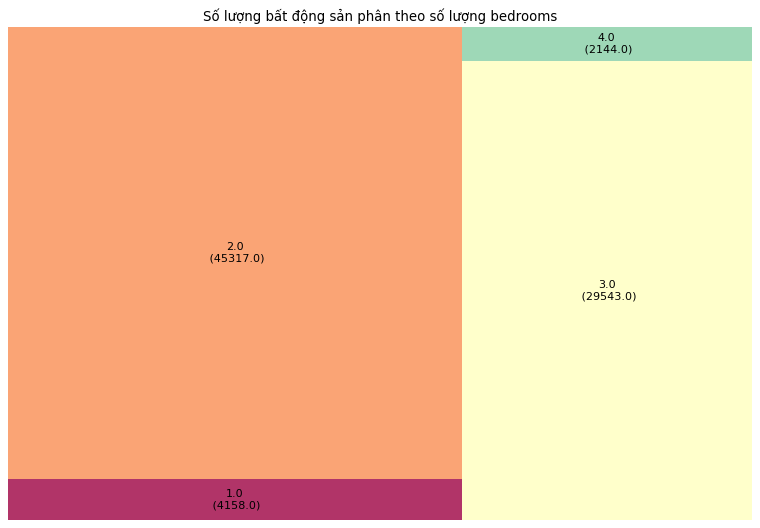

In [21]:
#Code ở đây
# Cài đặt thư viện squarify
!pip install squarify

import squarify
import matplotlib.pyplot as plt

# Gom nhóm dữ liệu theo số phòng ngủ và đếm số lượng
df = newdf.groupby('bedrooms').size().reset_index(name='counts')
# Tạo nhãn hiển thị: "Số PN \n (Số lượng)"
labels = df.apply(lambda x: str(x[0]) + "\n (" + str(x[1]) + ")", axis=1)

# Lấy danh sách các giá trị kích thước
sizes = df['counts'].values.tolist()

# Thiết lập bảng màu Spectral cho các khối
colors = [plt.cm.Spectral(i/float(len(labels))) for i in range(len(labels))]
plt.figure(figsize=(12, 8), dpi=80)

# Vẽ Treemap
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=.8)

# Thiết lập tiêu đề và ẩn trục
plt.title('Số lượng bất động sản phân theo số lượng bedrooms')
plt.axis('off')

plt.show()

* Giá bất động sản trung bình theo số lượng bedrooms

['darkblue', 'lightblue', 'peru', 'olivedrab', 'palegoldenrod']


C:\Users\ThinkBook 15 G5\AppData\Local\Temp\ipykernel_3720\1797697717.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df3['bedrooms'], rotation=60, horizontalalignment= 'right')


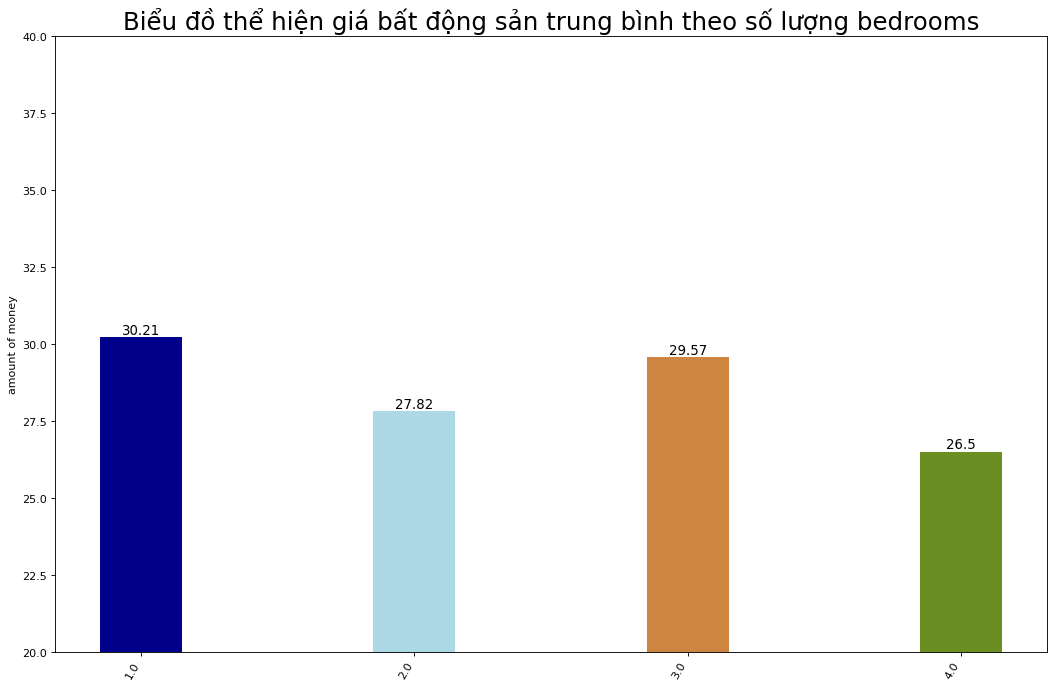

In [22]:
# Code ở đây
df3 = dftmp.groupby('bedrooms')['pricePerSquare'].mean().reset_index(name='amount of money')
# df3['amount of money'] = df3['amount of money'].apply(lambda x : int(str(x).split('.')[0]))
df3['amount of money'] = df3['amount of money'].apply(lambda x : round(x, 2))
df3['bedrooms'] = df3['bedrooms'].apply(lambda x : str(x))
n = df3['bedrooms'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
print(c)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df3['bedrooms'], df3['amount of money'], color=c, width=.3)
for i, val in enumerate(df3['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df3['bedrooms'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá bất động sản trung bình theo số lượng bedrooms", fontsize=22)
plt.ylim(20,40)
plt.ylabel('amount of money')
plt.show()

* Giá nhà đất trung bình theo quận (VND/m2)

In [ ]:
# Code ở đây
df2 = dftmp.groupby('district')['pricePerSquare'].mean().reset_index(name='amount of money')
df2 = df2.sort_values(by = 'amount of money') 
# df2['amount of money'] = df2['amount of money'].apply(lambda x : int(str(x).split('.')[0]))
df2['amount of money'] = df2['amount of money'].apply(lambda x : round(x, 2))
n = df2['district'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['district'], df2['amount of money'], color=c, width=.5)
for i, val in enumerate(df2['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df2['district'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo quận (VND/m2)", fontsize=22)
plt.ylabel('amount of money')
# plt.ylim(25,35)
plt.show()

* Giá nhà đất trung bình theo các phường quận Hoàn Kiếm (VND/m2)

In [ ]:
# Code ở đây
hoan_kiem = dftmp.loc[(dftmp['district'] == 'hoan kiem')]
df2 = hoan_kiem.groupby('ward')['pricePerSquare'].mean().reset_index(name='amount of money')
df2 = df2.sort_values(by = 'amount of money') 
# df2['amount of money'] = df2['amount of money'].apply(lambda x : int(str(x).split('.')[0]))
df2['amount of money'] = df2['amount of money'].apply(lambda x : round(x, 2))
n = df2['ward'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['ward'], df2['amount of money'], color=c, width=.5)
for i, val in enumerate(df2['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df2['ward'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo các phường quận Hoàn Kiếm (VND/m2)", fontsize=22)
plt.ylabel('amount of money')
# plt.ylim(25,35)
plt.show()

* Giá nhà đất trung bình theo nhà đầu tư (VND/m2)

In [ ]:
# Code ở đây
df2 = dftmp.groupby('investor')['pricePerSquare'].mean().reset_index(name='amount of money')
df2 = df2.sort_values(by = 'amount of money', ascending= False).head(10)
# df2['amount of money'] = df2['amount of money'].apply(lambda x : int(str(x).split('.')[0]))
df2['amount of money'] = df2['amount of money'].apply(lambda x : round(x, 2))
n = df2['investor'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['investor'], df2['amount of money'], color=c, width=.5)
for i, val in enumerate(df2['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df2['investor'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo nhà đầu tư (VND/m2)", fontsize=22)
plt.ylabel('amount of money')
plt.ylim(30,70)
plt.show()

* Giá nhà đất trung bình theo dự án (VND/m2)

C:\Users\ThinkBook 15 G5\AppData\Local\Temp\ipykernel_3720\4026023362.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df2['project'], rotation=60, horizontalalignment= 'right')


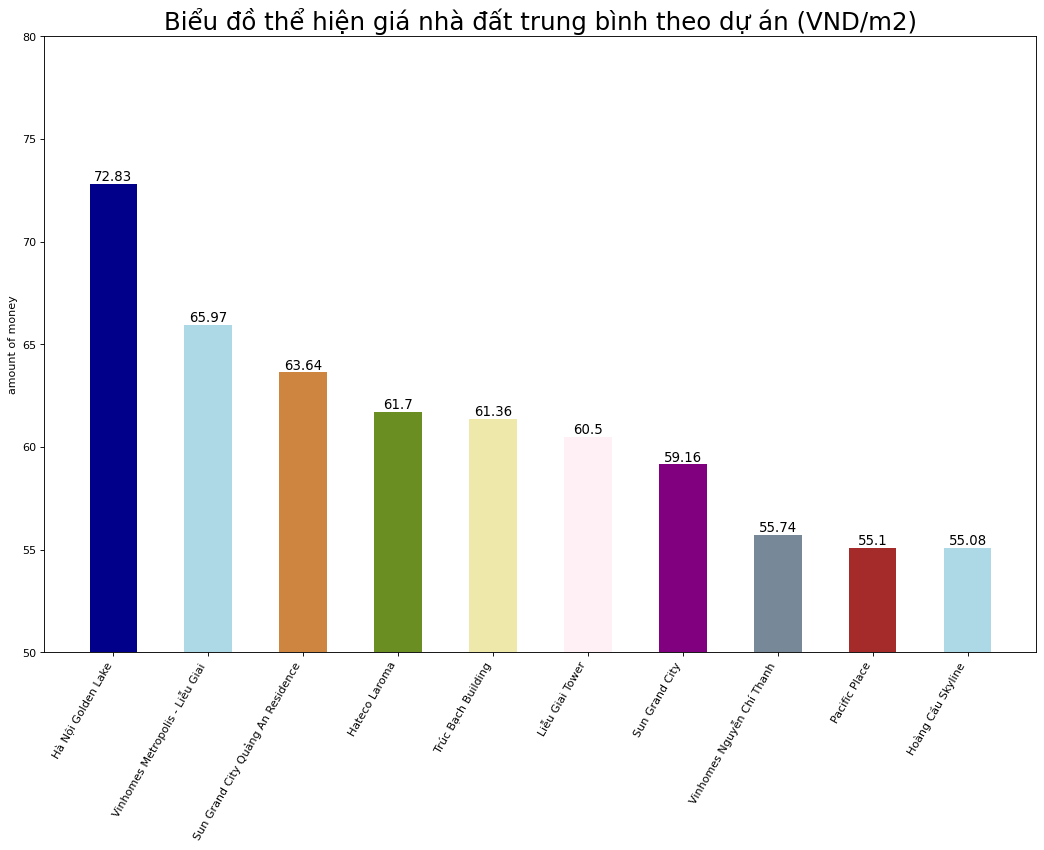

In [24]:
# Code ở đây
df2 = dftmp.groupby('project')['pricePerSquare'].mean().reset_index(name='amount of money')
df2 = df2.sort_values(by = 'amount of money', ascending= False).head(10)
# df2['amount of money'] = df2['amount of money'].apply(lambda x : int(str(x).split('.')[0]))
df2['amount of money'] = df2['amount of money'].apply(lambda x : round(x, 2))
n = df2['project'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['project'], df2['amount of money'], color=c, width=.5)
for i, val in enumerate(df2['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df2['project'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo dự án (VND/m2)", fontsize=22)
plt.ylabel('amount of money')
plt.ylim(50,80)
plt.show()

* Giá bất động sản phân bố theo top 10 nhà đầu tư triệu /m2

['Công ty CP Đầu tư Trúc Bạch' 'Tập đoàn Sun Group'
 'Tập đoàn Jaccar Bourbon' 'Công ty Liên doanh Hà Việt – Tungshing'
 'Công ty TNHH Đầu tư C.T.L' 'Công ty CP Đầu tư Phát triển nhà Gia Bảo'
 'Công ty CP Tân Phú Long'
 'Tổng công ty Xây dựng Thanh Hóa - Công ty Cổ phần'
 'Công ty CP ACC - Thăng Long' 'Tập đoàn BRG']


C:\Users\ThinkBook 15 G5\AppData\Local\Temp\ipykernel_3720\2561688728.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df2['investor'], rotation=60, horizontalalignment= 'right')


Text(0.5, 1.0, 'Giá bất động sản phân bố theo top 10 nhà đầu tư triệu /m2')

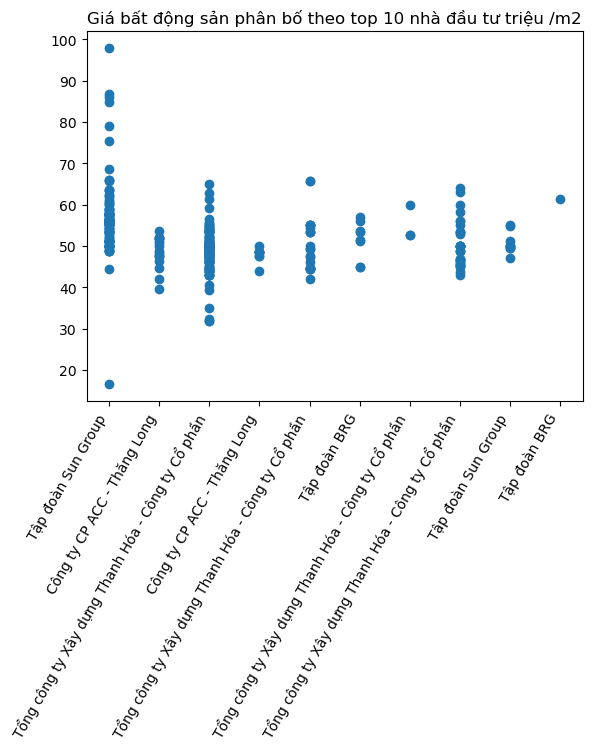

In [23]:
# Code ở đây
inves = dftmp[dftmp['investor'].notnull()]
inves = inves.groupby('investor')['pricePerSquare'].mean().reset_index(name='amount of money')
inves = inves.sort_values(by = 'amount of money', ascending= False).head(10)
topInves = inves['investor'].unique()
print(topInves)
df2 = dftmp.loc[dftmp['investor'].isin(topInves)]
 
plt.scatter(df2.investor, df2.pricePerSquare)
# plt.ylim(0,100)
plt.gca().set_xticklabels(df2['investor'], rotation=60, horizontalalignment= 'right')
plt.title("Giá bất động sản phân bố theo top 10 nhà đầu tư triệu /m2")

* Giá bất động sản phân bố theo dự án

['Hà Nội Golden Lake' 'Vinhomes Metropolis - Liễu Giai'
 'Sun Grand City Quảng An Residence' 'Hateco Laroma' 'Trúc Bạch Building'
 'Liễu Giai Tower' 'Sun Grand City' 'Vinhomes Nguyễn Chí Thanh'
 'Pacific Place' 'Hoàng Cầu Skyline']
             id month                          project  \
217    27988796    12                   Sun Grand City   
320    28111000    12                  Liễu Giai Tower   
382    24458492    12        Vinhomes Nguyễn Chí Thanh   
633    28125955    12        Vinhomes Nguyễn Chí Thanh   
679    25436762    12        Vinhomes Nguyễn Chí Thanh   
...         ...   ...                              ...   
74247  25937912    06  Vinhomes Metropolis - Liễu Giai   
74265  25567443    06                Hoàng Cầu Skyline   
75470  25907355    06                Hoàng Cầu Skyline   
80552  25747362    06  Vinhomes Metropolis - Liễu Giai   
80976  24208962    06        Vinhomes Nguyễn Chí Thanh   

                                                investor  square  bedro

C:\Users\ThinkBook 15 G5\AppData\Local\Temp\ipykernel_3720\1889576337.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df7['project'], rotation=60, horizontalalignment= 'right')


Text(0.5, 1.0, 'Giá bất động sản phân bố theo dự án triệu VND/m2 ')

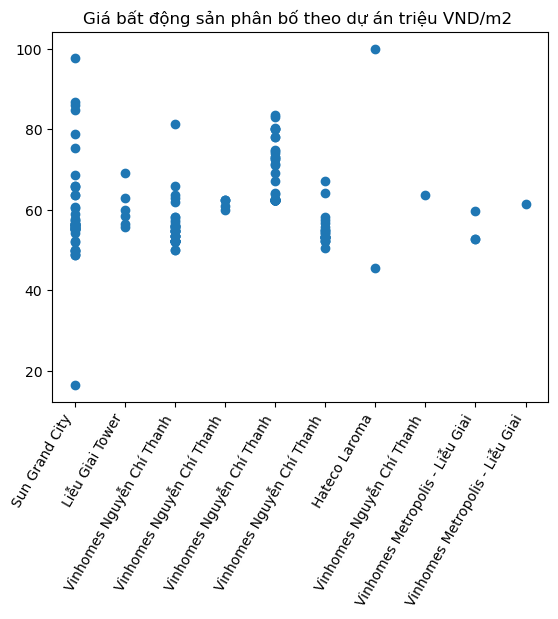

In [25]:
# Code ở đây
pr = dftmp[dftmp['project'].notnull()]
pr = pr.groupby('project')['pricePerSquare'].mean().reset_index(name='amount of money')
pr = pr.sort_values(by = 'amount of money', ascending= False).head(10)
protop = pr['project'].unique()
print(protop)
df7 = dftmp.loc[(dftmp['project'].isin(protop))]
print(df7)
plt.scatter(df7.project, df7.pricePerSquare)
# plt.ylim(0,150)
plt.gca().set_xticklabels(df7['project'], rotation=60, horizontalalignment= 'right')
plt.title("Giá bất động sản phân bố theo dự án triệu VND/m2 ")

* Giá nhà đất trung bình theo hướng nhà (VND/m2)

['Nam' 'Bắc' 'Tây' 'Đông' 'none' 'Tây-Bắc' 'Tây-Nam' 'Đông-Nam']
['Đông-Nam' 'none' 'Tây-Bắc' 'Tây-Nam' 'Bắc' 'Nam' 'Đông' 'Tây']


Text(0.5, 1.0, 'Giá bất động sản phân bố theo hướng nhà triệu VND/m2 ')

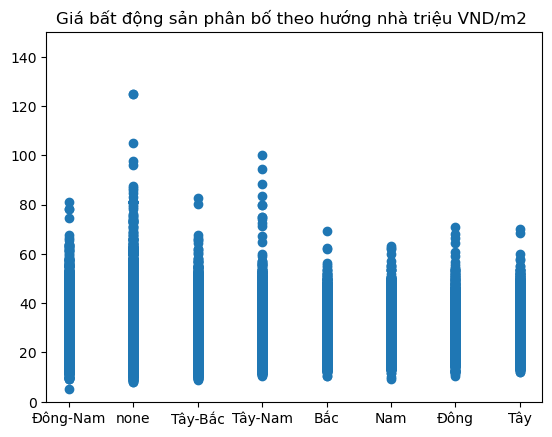

In [26]:
# Code ở đây
direct = dftmp.copy()
direct['direction'] = direct['direction'].apply(lambda x : 'none' if pd.isnull(x) == True else x )
# dir = dftmp[dftmp['direction'].notnull()]
dir = direct.groupby('direction')['pricePerSquare'].mean().reset_index(name='amount of money')
dir = dir.sort_values(by = 'amount of money', ascending= False).head(8)
topDir = dir['direction'].unique()
print(topDir)
df8 = direct.loc[direct['direction'].isin(topDir)]
print(df8['direction'].unique())
plt.scatter(df8.direction, df8.pricePerSquare)
plt.ylim(0,150)
# plt.gca().set_xticklabels(horizontalalignment= 'right')
plt.title("Giá bất động sản phân bố theo hướng nhà triệu VND/m2 ")

C:\Users\ThinkBook 15 G5\AppData\Local\Temp\ipykernel_3720\1053910596.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df2['direction'], rotation=60, horizontalalignment= 'right')


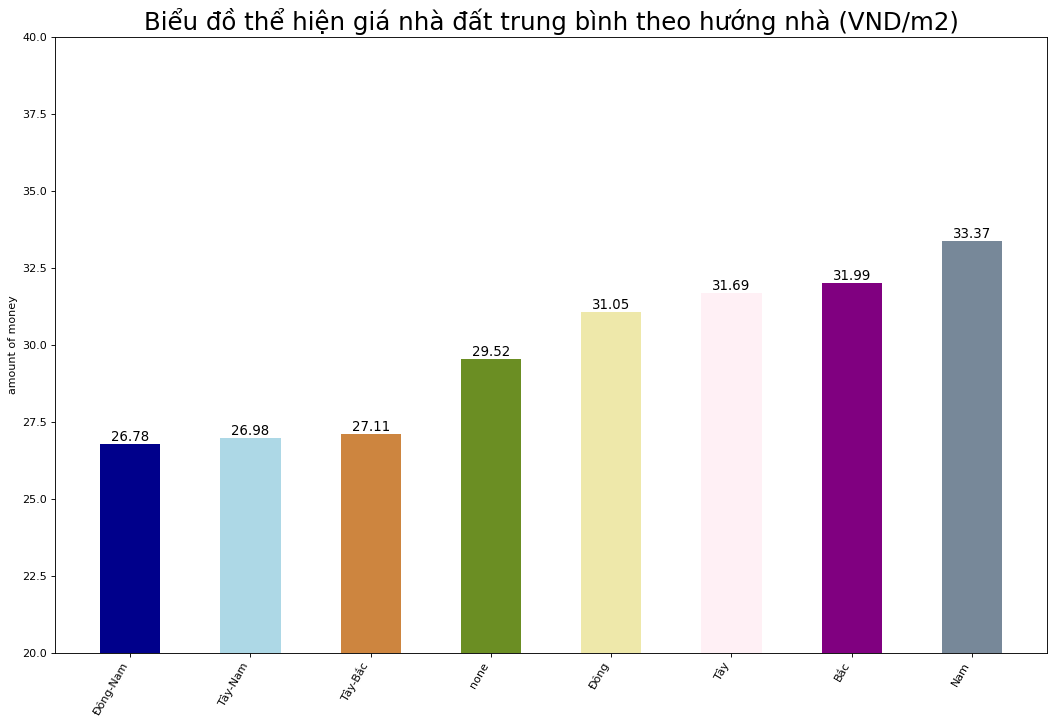

In [27]:
# Code ở đây
df2 = df8.groupby('direction')['pricePerSquare'].mean().reset_index(name='amount of money')
df2 = df2.sort_values(by = 'amount of money') 
# df2['amount of money'] = df2['amount of money'].apply(lambda x : int(str(x).split('.')[0]))
df2['amount of money'] = df2['amount of money'].apply(lambda x : round(x, 2))
n = df2['direction'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['direction'], df2['amount of money'], color=c, width=.5)
for i, val in enumerate(df2['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df2['direction'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo hướng nhà (VND/m2)", fontsize=22)
plt.ylabel('amount of money')
plt.ylim(20,40)
plt.show()

3. Tương quan giữa các trường thuộc tính

* https://vi.wikipedia.org/wiki/H%E1%BB%87_s%E1%BB%91_t%C6%B0%C6%A1ng_quan
* bieu do the hien he so tuong quan giua cac cap bien so thuc banggf biểu đồ heatmap

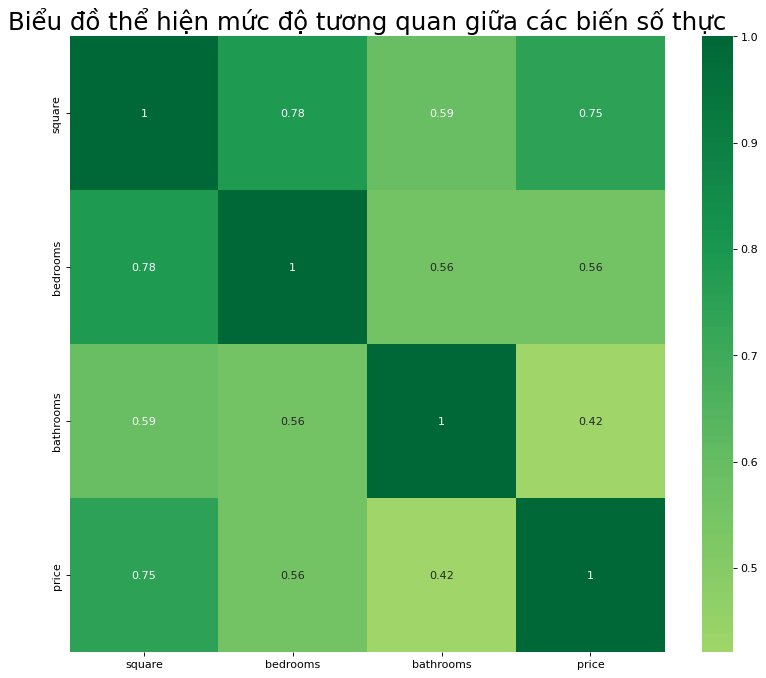

In [32]:
# Gợi ý: sns.heatmap(cmap='RdYlGn', ...)
# Tính toán ma trận tương quan trước để code gọn và tránh lỗi
corr_matrix = newdf.corr(numeric_only=True)

# Vẽ heatmap
plt.figure(figsize=(12,10), dpi= 80)
sns.heatmap(corr_matrix, 
            xticklabels=corr_matrix.columns, 
            yticklabels=corr_matrix.columns, 
            cmap='RdYlGn', 
            center=0, 
            annot=True)

plt.title('Biểu đồ thể hiện mức độ tương quan giữa các biến số thực', fontsize=22)
plt.show()

* bieu do the hien moi quan he giua cac bien so thuc với biểu đồ phân tán

<Figure size 800x640 with 0 Axes>

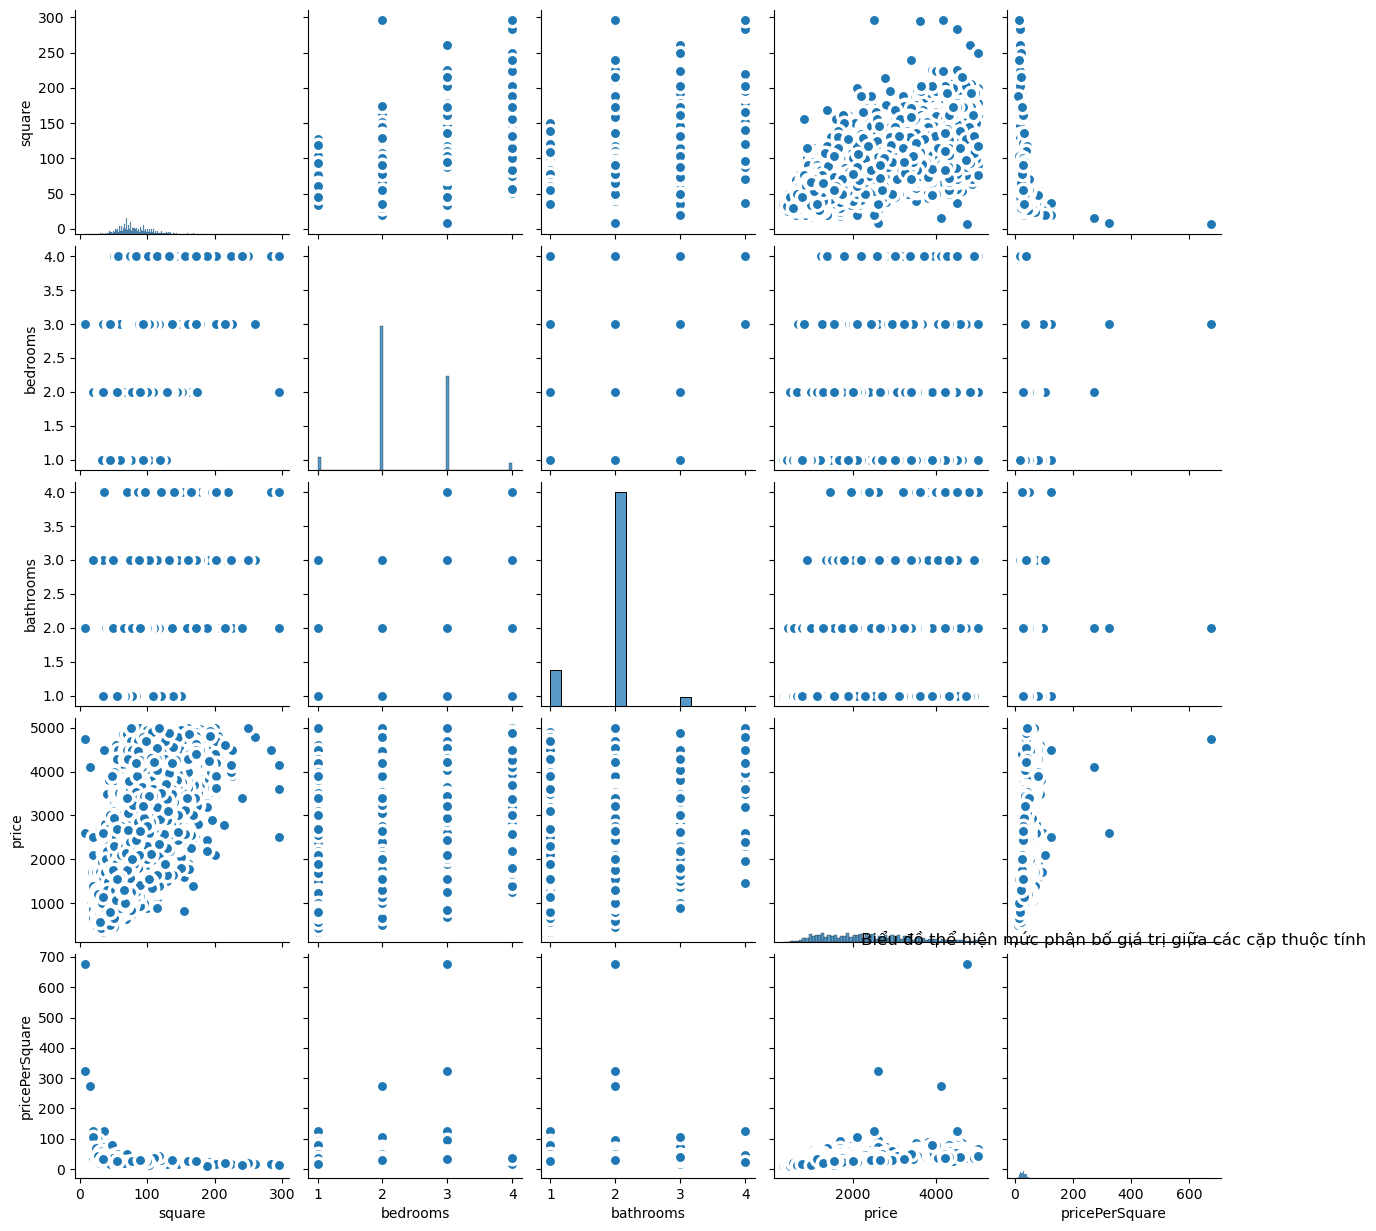

In [33]:
#Gợi ý: sns.pairplot(kind='scatter', ...)
plt.figure(figsize=(10,8), dpi= 80)
sns.pairplot(dftmp, kind="scatter", plot_kws=dict(s=80, edgecolor="white", linewidth=2.5))
plt.title('Biểu đồ thể hiện mức phân bố giá trị giữa các cặp thuộc tính')
plt.show()


4. Mật độ giá nhà trung bình theo quận 

(0.0, 100.0)

<Figure size 640x480 with 0 Axes>

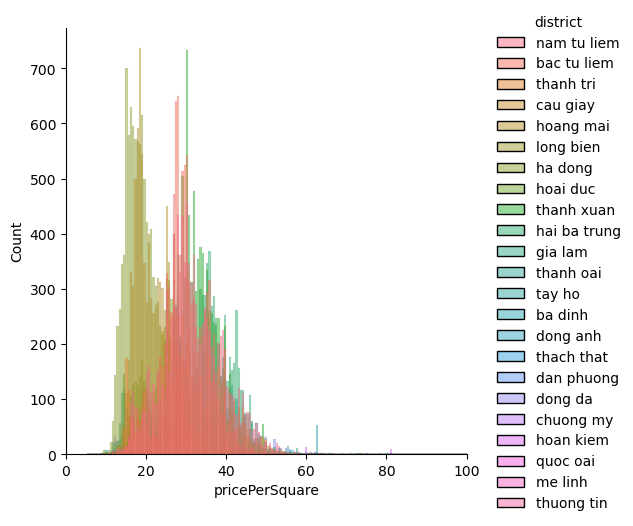

In [34]:
#Gợi ý: sns.displot()
df5 = dftmp.copy()
plt.clf()
sns.displot(df5, x="pricePerSquare", hue="district")
plt.xlim(0, 100)

End :))